<a href="https://colab.research.google.com/github/bingjunw/ust-deep-learning-2026/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5

**Load Libraries and Set Up Data**

In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import Image, display
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import imageio
import os

In [2]:
# Set the random seed
SEED = 2026
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Function to load and preprocess the single-cell data
def load_data(file_path):
    df = pd.read_csv(file_path, index_col=0)
    X = df.drop(columns=['group']).fillna(0).values
    X = np.log1p(X)
    le = LabelEncoder()
    y_int = le.fit_transform(df['group'].values)
    num_classes = len(le.classes_)

    X_scaled = StandardScaler().fit_transform(X)
    x_train, x_test, y_train, y_test = train_test_split(
        X_scaled, y_int, test_size=0.2, random_state=SEED, stratify=y_int
    )

    return x_train, tf.keras.utils.to_categorical(y_train, num_classes), \
           x_test, tf.keras.utils.to_categorical(y_test, num_classes), \
           num_classes, X_scaled, y_int, le.classes_

In [3]:
# Load the data
x_train, y_train, x_test, y_test, num_classes, X_all, y_all, group_names = load_data('single_cell.csv')

**Define the Model Architectures**

In [4]:
# Create the classifier model for visualization
def create_model(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(2, name='latent_layer'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = create_model(x_train.shape[1], num_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callback to save frames for GIF
if not os.path.exists('frames'): os.makedirs('frames')
image_files = []

class VisualizerCallback(callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.latent_model = None # Initialize to None
    def set_model(self, model):
        super().set_model(model)
        # Create the latent_model here, once the main model is set and built
        self.latent_model = models.Model(
            inputs=self.model.layers[0].input,
            outputs=self.model.get_layer('latent_layer').output
        )
    def on_epoch_end(self, epoch, logs=None):
        res = self.latent_model.predict(X_all, verbose=0)
        plt.figure(figsize=(8, 6))
        plt.xlim(-15, 15); plt.ylim(-15, 15)
        scatter = plt.scatter(res[:, 0], res[:, 1], c=y_all,
                              s=50, edgecolors='white', linewidth=0.5, alpha=0.9)
        handles = scatter.legend_elements()[0]
        plt.legend(handles, group_names, title="Groups", loc="upper right")
        plt.title(f"Cell Embedding - Epoch {epoch+1:03d}")
        plt.xlabel("Latent 1"); plt.ylabel("Latent 2")
        fname = f'frames/e_{epoch+1:03d}.png'
        plt.savefig(fname)
        plt.close()
        image_files.append(fname)

**Training loop and visualization**

In [5]:
# Train the model
model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=45,
    batch_size=16,
    callbacks=[VisualizerCallback()],
    verbose=1
)

Epoch 1/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 358ms/step - accuracy: 0.2050 - loss: 1.7049 - val_accuracy: 0.3000 - val_loss: 1.5007
Epoch 2/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.2806 - loss: 1.4489 - val_accuracy: 0.2500 - val_loss: 1.4759
Epoch 3/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4014 - loss: 1.2501 - val_accuracy: 0.1500 - val_loss: 1.4681
Epoch 4/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4521 - loss: 1.1648 - val_accuracy: 0.2000 - val_loss: 1.4633
Epoch 5/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.4840 - loss: 1.1764 - val_accuracy: 0.2000 - val_loss: 1.4610
Epoch 6/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4807 - loss: 1.0437 - val_accuracy: 0.3000 - val_loss: 1.4601
Epoch 7/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.5535 - loss: 1.0134 - val_accuracy: 0.2500 - val_loss: 1.4599
Epoch 8/45
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5396 - loss: 0.9319 - val_accuracy: 0.2500 - val_loss: 1.4

In [10]:
# Generate the gif
gif_name = 'Single_Cell_Evolution.gif'
with imageio.get_writer(gif_name, mode='I', duration=0.1) as writer:
    for f in image_files:
        writer.append_data(imageio.imread(f))

/tmp/ipython-input-647855630.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(f))


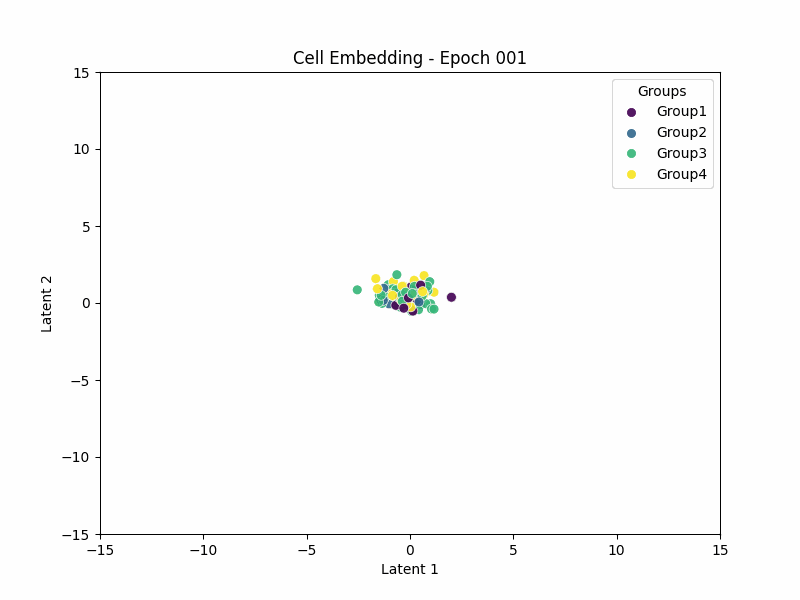